# Tutorial 2 - multiple stellar lines in the fitting window

When several stellar lines fall inside the window, a single-line model has to absorb them.
`MCMC-RVSD` lets you add any number of lines: each `StellarLine(name, center)` adds three
parameters, so the number of components has to be chosen rather than guessed.  The paper compares
two configurations, both reproduced here:

* **(a) blended** - three real stellar lines near $6613.7\,\rm\AA$ (Fe I 6613.825, Th I 6613.416,
  Y II 6613.731). At the LAMOST MRS resolution the instrumental FWHM is
  $\lambda/R\approx0.88\,\rm\AA$, so this trio is unresolved;
* **(b) unblended** - the same three lines spread over the window (6613.825, 6612.325, 6615.325)
  so that they are clearly separated.

Adding a component always improves the fit, so the optimal number of stellar lines is selected
with the information criteria $\Delta$AIC and $\Delta$BIC (lower is better; the model with
$\Delta$AIC = 0 wins).  Both are evaluated at the **best-fitting sample of the chain**: when some
parameters are degenerate, their marginal posterior medians do not combine into a good joint fit,
and using them would distort the comparison.

In [1]:
%matplotlib inline
import json, sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:                                     # installed with `pip install -e .`
    import mcmc_rvsd
except ImportError:                      # or run straight from a clone
    sys.path.insert(0, str(Path.cwd().parent / 'src'))
    import mcmc_rvsd
from mcmc_rvsd import SpectralModel, StellarLine, DIB, run_mcmc, plotting
from mcmc_rvsd.io import load_result, load_mock
from mcmc_rvsd.selection import aic, best_sample_lnL, bic, chi2_lnL

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
FIG = ROOT / 'docs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
RERUN = False             # set to True to redo the MCMC yourself (a few minutes per model)
print('mcmc_rvsd', mcmc_rvsd.__version__, '|',
      'running from a repository clone' if (ROOT / 'data').is_dir() else 'running from an installed package')

mcmc_rvsd 0.1.0 | running from a repository clone


In [2]:
# one StellarLine per centre: 3 parameters per line + 3 for the DIB
def build_model(centers, dib_gauss=True):
    return SpectralModel(
        stellar_lines=[StellarLine(name, c, center_bounds=(6611.5, 6617.0)) for name, c in centers],
        dib=DIB(profile='gaussian' if dib_gauss else 'voigt'))


# run the MCMC (RERUN) or read the precomputed result
def fit_or_load(key, model, data, stars=None, dib0=None):
    if RERUN:
        p0 = model.initial_guess(stars=stars, dib=dib0)
        res = run_mcmc(model, data['wave_analysis'], data['fluxs'], data['y_errs'],
                       data['rv_obs'], data['rv_err'], p0=p0,
                       snrs=np.full(len(data['rv_obs']), 200.0), seed=42)
        res.save(ROOT / f'examples/results/{key}.npz', thin=10)
    else:
        res = load_result(ROOT / f'examples/results/{key}.npz')
    return model, res


# AIC/BIC at the best-fitting sample of the chain (a joint estimate, see mcmc_rvsd.selection)
def information_criteria(model, res, data):
    lnL, _ = best_sample_lnL(model, res.samples, data['wave_analysis'], data['fluxs'],
                             data['y_errs'], data['rv_obs'])
    k, n = model.n_params, data['fluxs'].size
    return lnL, aic(lnL, k), bic(lnL, k, n)

## 1. Configuration (a): three blended lines

In [3]:
data_a = load_mock(ROOT / 'data/mock/mock_multistar.npz')
stars_a = list(data_a['stellar_lines'])
dib = data_a['dib_truth'].item()
print('window {:.2f}-{:.2f} A | {} pixels | instrumental FWHM ~ {:.2f} A at R=7500'
      .format(data_a['wave_analysis'][0], data_a['wave_analysis'][-1],
              data_a['wave_analysis'].size, 6613.7 / 7500))
for s in stars_a:
    print(f"  stellar {s['name']:>4}: centre {s['center']:.3f} A, depth {s['strength']:.4f}, sigma {s['sigma']:.3f}")
print(f"  DIB        : centre {dib['center']:.3f} A, depth {dib['strength']:.4f}, sigma {dib['sigma']:.3f}")

window 6611.50-6616.90 A | 46 pixels | instrumental FWHM ~ 0.88 A at R=7500
  stellar  FeI: centre 6613.825 A, depth 0.0110, sigma 0.380
  stellar  ThI: centre 6613.416 A, depth 0.0111, sigma 0.416
  stellar  YII: centre 6613.731 A, depth 0.0066, sigma 0.378
  DIB        : centre 6613.709 A, depth 0.0490, sigma 0.546


All three lines lie within $\sim0.4\,\rm\AA$ of each other, i.e. inside one resolution element: the
observed feature is one absorption whose shape is set by the instrumental profile.

In [4]:
CENTERS = [('FeI', 6613.825), ('ThI', 6613.416), ('YII', 6613.731)]
rows_a = []
for n in (1, 3):
    key = f'mock_multistar_{n}line'
    model = build_model(CENTERS[:n])
    model, res = fit_or_load(key, model, data_a,
                             stars=[[s['center'], s['strength'], s['sigma']] for s in stars_a][:n],
                             dib0=[dib['center'], dib['strength'], dib['sigma']])
    lnL, A, B = information_criteria(model, res, data_a)
    q = res.pfit[3 * n:]
    rows_a.append((n, A, B, q, res))
    print(f'{n}-line model: k = {model.n_params:2d} | lnL(best) = {lnL:8.2f} | AIC = {A:8.2f} | BIC = {B:8.2f} | '
          f'DIB: lambda = {q[0]:.3f}, A = {q[1]:.4f}, sigma = {q[2]:.3f} | label = {res.label}')
A_min = min(r[1] for r in rows_a); B_min = min(r[2] for r in rows_a)
print()
for n, A, B, q, res in rows_a:
    print(f'  {n}-line: Delta AIC = {A - A_min:+.1f} | Delta BIC = {B - B_min:+.1f}')
print(f'  input   : DIB lambda = {dib["center"]:.3f}, A = {dib["strength"]:.4f}, sigma = {dib["sigma"]:.3f}')

1-line model: k =  6 | lnL(best) =  -532.03 | AIC =  1076.06 | BIC =  1106.10 | DIB: lambda = 6613.696, A = 0.0492, sigma = 0.551 | label = Success


3-line model: k = 12 | lnL(best) =  -527.21 | AIC =  1078.42 | BIC =  1138.50 | DIB: lambda = 6613.698, A = 0.0493, sigma = 0.551 | label = Severe Degeneracy

  1-line: Delta AIC = +0.0 | Delta BIC = +0.0
  3-line: Delta AIC = +2.4 | Delta BIC = +32.4
  input   : DIB lambda = 6613.709, A = 0.0490, sigma = 0.546


In the blended configuration the extra lines are not required by the data: $\Delta$AIC and
$\Delta$BIC are minimal for the 1-line model, and the DIB parameters agree between the two models
within the uncertainties.  Note the label of the 12-parameter fit as well - its autocorrelation
time is much larger, i.e. its parameters are partly degenerate, a hint that the extra components
are not constrained by the data.

## 2. Configuration (b): three unblended lines

In [5]:
data_b = load_mock(ROOT / 'data/mock/mock_multistar_unblended.npz')
stars_b = list(data_b['stellar_lines'])
dib_b = data_b['dib_truth'].item()
UNBLENDED = [('FeI', 6613.825), ('ThI', 6612.325), ('YII', 6615.325)]
for s in stars_b:
    print(f"  stellar {s['name']:>4}: centre {s['center']:.3f} A, depth {s['strength']:.4f}, sigma {s['sigma']:.3f}")
print(f"  DIB        : centre {dib_b['center']:.3f} A, depth {dib_b['strength']:.4f}, sigma {dib_b['sigma']:.3f}")

  stellar  FeI: centre 6613.825 A, depth 0.0110, sigma 0.380
  stellar  ThI: centre 6612.325 A, depth 0.0111, sigma 0.416
  stellar  YII: centre 6615.325 A, depth 0.0066, sigma 0.378
  DIB        : centre 6613.709 A, depth 0.0490, sigma 0.546


In [6]:
rows_b = []
for n in (1, 3):
    key = f'mock_unblended_{n}line'
    model = build_model(UNBLENDED[:n])
    model, res = fit_or_load(key, model, data_b,
                             stars=[[s['center'], s['strength'], s['sigma']] for s in stars_b][:n],
                             dib0=[dib_b['center'], dib_b['strength'], dib_b['sigma']])
    lnL, A, B = information_criteria(model, res, data_b)
    q, e = res.pfit[3 * n:], res.perr[3 * n:]
    rows_b.append((n, A, B, q, e, res))
    print(f'{n}-line model: k = {model.n_params:2d} | AIC = {A:8.2f} | BIC = {B:8.2f} | '
          f'DIB: lambda = {q[0]:.3f}, A = {q[1]:.4f} (+/- {e[1]:.4f}), sigma = {q[2]:.3f} | label = {res.label}')
A_min_b = min(r[1] for r in rows_b); B_min_b = min(r[2] for r in rows_b)
print()
for n, A, B, q, e, res in rows_b:
    print(f'  {n}-line: Delta AIC = {A - A_min_b:+.1f} | Delta BIC = {B - B_min_b:+.1f} | '
          f'DIB depth offset {(q[1] - dib_b["strength"]) / e[1]:+.1f} sigma')
print(f'  input   : DIB lambda = {dib_b["center"]:.3f}, A = {dib_b["strength"]:.4f}, sigma = {dib_b["sigma"]:.3f}')

1-line model: k =  6 | AIC =  1330.39 | BIC =  1360.43 | DIB: lambda = 6613.701, A = 0.0511 (+/- 0.0005), sigma = 0.585 | label = Success


3-line model: k = 12 | AIC =  1069.86 | BIC =  1129.94 | DIB: lambda = 6613.699, A = 0.0497 (+/- 0.0005), sigma = 0.556 | label = Mild Degeneracy

  1-line: Delta AIC = +260.5 | Delta BIC = +230.5 | DIB depth offset +4.3 sigma
  3-line: Delta AIC = +0.0 | Delta BIC = +0.0 | DIB depth offset +1.5 sigma
  input   : DIB lambda = 6613.709, A = 0.0490, sigma = 0.546


Here the model matters.  With one stellar line the two missing absorptions are absorbed by the DIB,
which comes out deeper and broader than the input; $\Delta$AIC and $\Delta$BIC both drop clearly
when all three lines are modelled, i.e. the 3-line model is the optimal description.

## 3. The two models on the unblended data

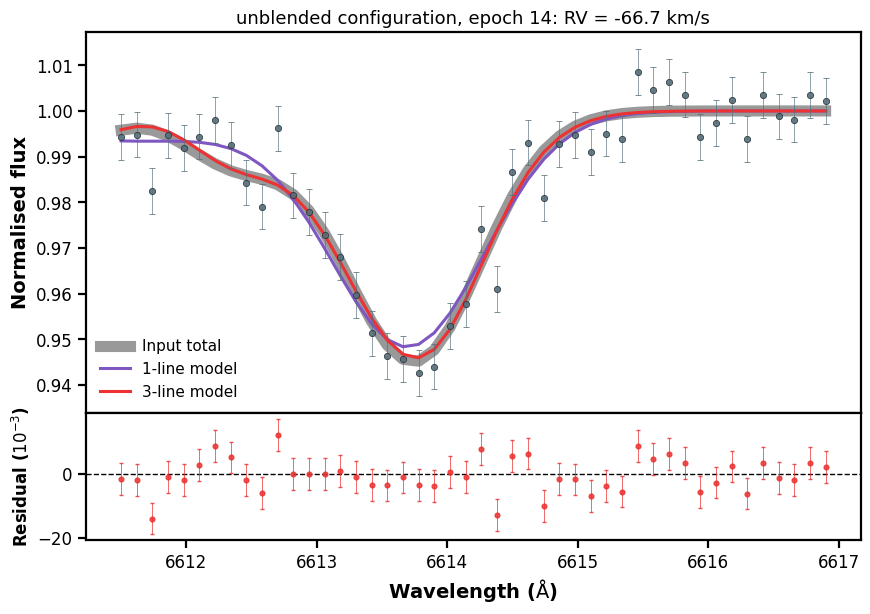

In [7]:
from mcmc_rvsd import plotting as P

i = int(np.argmax(np.abs(data_b['rv_obs'])))
wave, flux, err = data_b['wave_analysis'], data_b['fluxs'], data_b['y_errs']
model1, model3 = build_model(UNBLENDED[:1]), build_model(UNBLENDED[:3])
truth = np.concatenate([[s[k] for s in stars_b for k in ('center', 'strength', 'sigma')],
                        [dib_b['center'], dib_b['strength'], dib_b['sigma']]])

fig, axes = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1], hspace=0.0))
ax = axes[0]
ax.plot(wave, model3.flux(wave, data_b['rv_obs'][i], truth), color='k', lw=8, alpha=0.4,
        zorder=1, label='Input total')
ax.plot(wave, model1.flux(wave, data_b['rv_obs'][i], rows_b[0][5].pfit), color='#7E57C2', lw=2.2,
        zorder=8, label='1-line model')
ax.plot(wave, model3.flux(wave, data_b['rv_obs'][i], rows_b[1][5].pfit), color=P.C_GAUSS, lw=2.2,
        zorder=9, label='3-line model')
ax.errorbar(wave, flux[i], yerr=err[i], fmt='o', ms=4.5, color=P.C_DATA, alpha=0.9,
            markeredgewidth=0.6, markeredgecolor='#263238', capsize=2, elinewidth=0.5, zorder=10)
P.style_axes(ax)
ax.set_ylabel('Normalised flux', fontsize=14, fontweight='bold')
ax.set_title(f'unblended configuration, epoch {i}: RV = {data_b["rv_obs"][i]:+.1f} km/s', fontsize=13)
ax.legend(frameon=False, fontsize=11, loc='lower left')

res3 = model3.flux(wave, data_b['rv_obs'][i], rows_b[1][5].pfit)
axes[1].errorbar(wave, (flux[i] - res3) * 1e3, yerr=err[i] * 1e3, fmt='o', ms=3.4,
                 color=P.C_GAUSS, alpha=0.85, capsize=1.6, elinewidth=0.6, zorder=6)
axes[1].axhline(0, color='k', ls='--', lw=1)
P.style_axes(axes[1])
axes[1].set_xlabel(r'Wavelength ($\rm\AA$)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Residual ($10^{-3}$)', fontsize=12, fontweight='bold')
fig.savefig(FIG / 'nb02_unblended_fit.png', dpi=300, bbox_inches='tight')
plt.show()

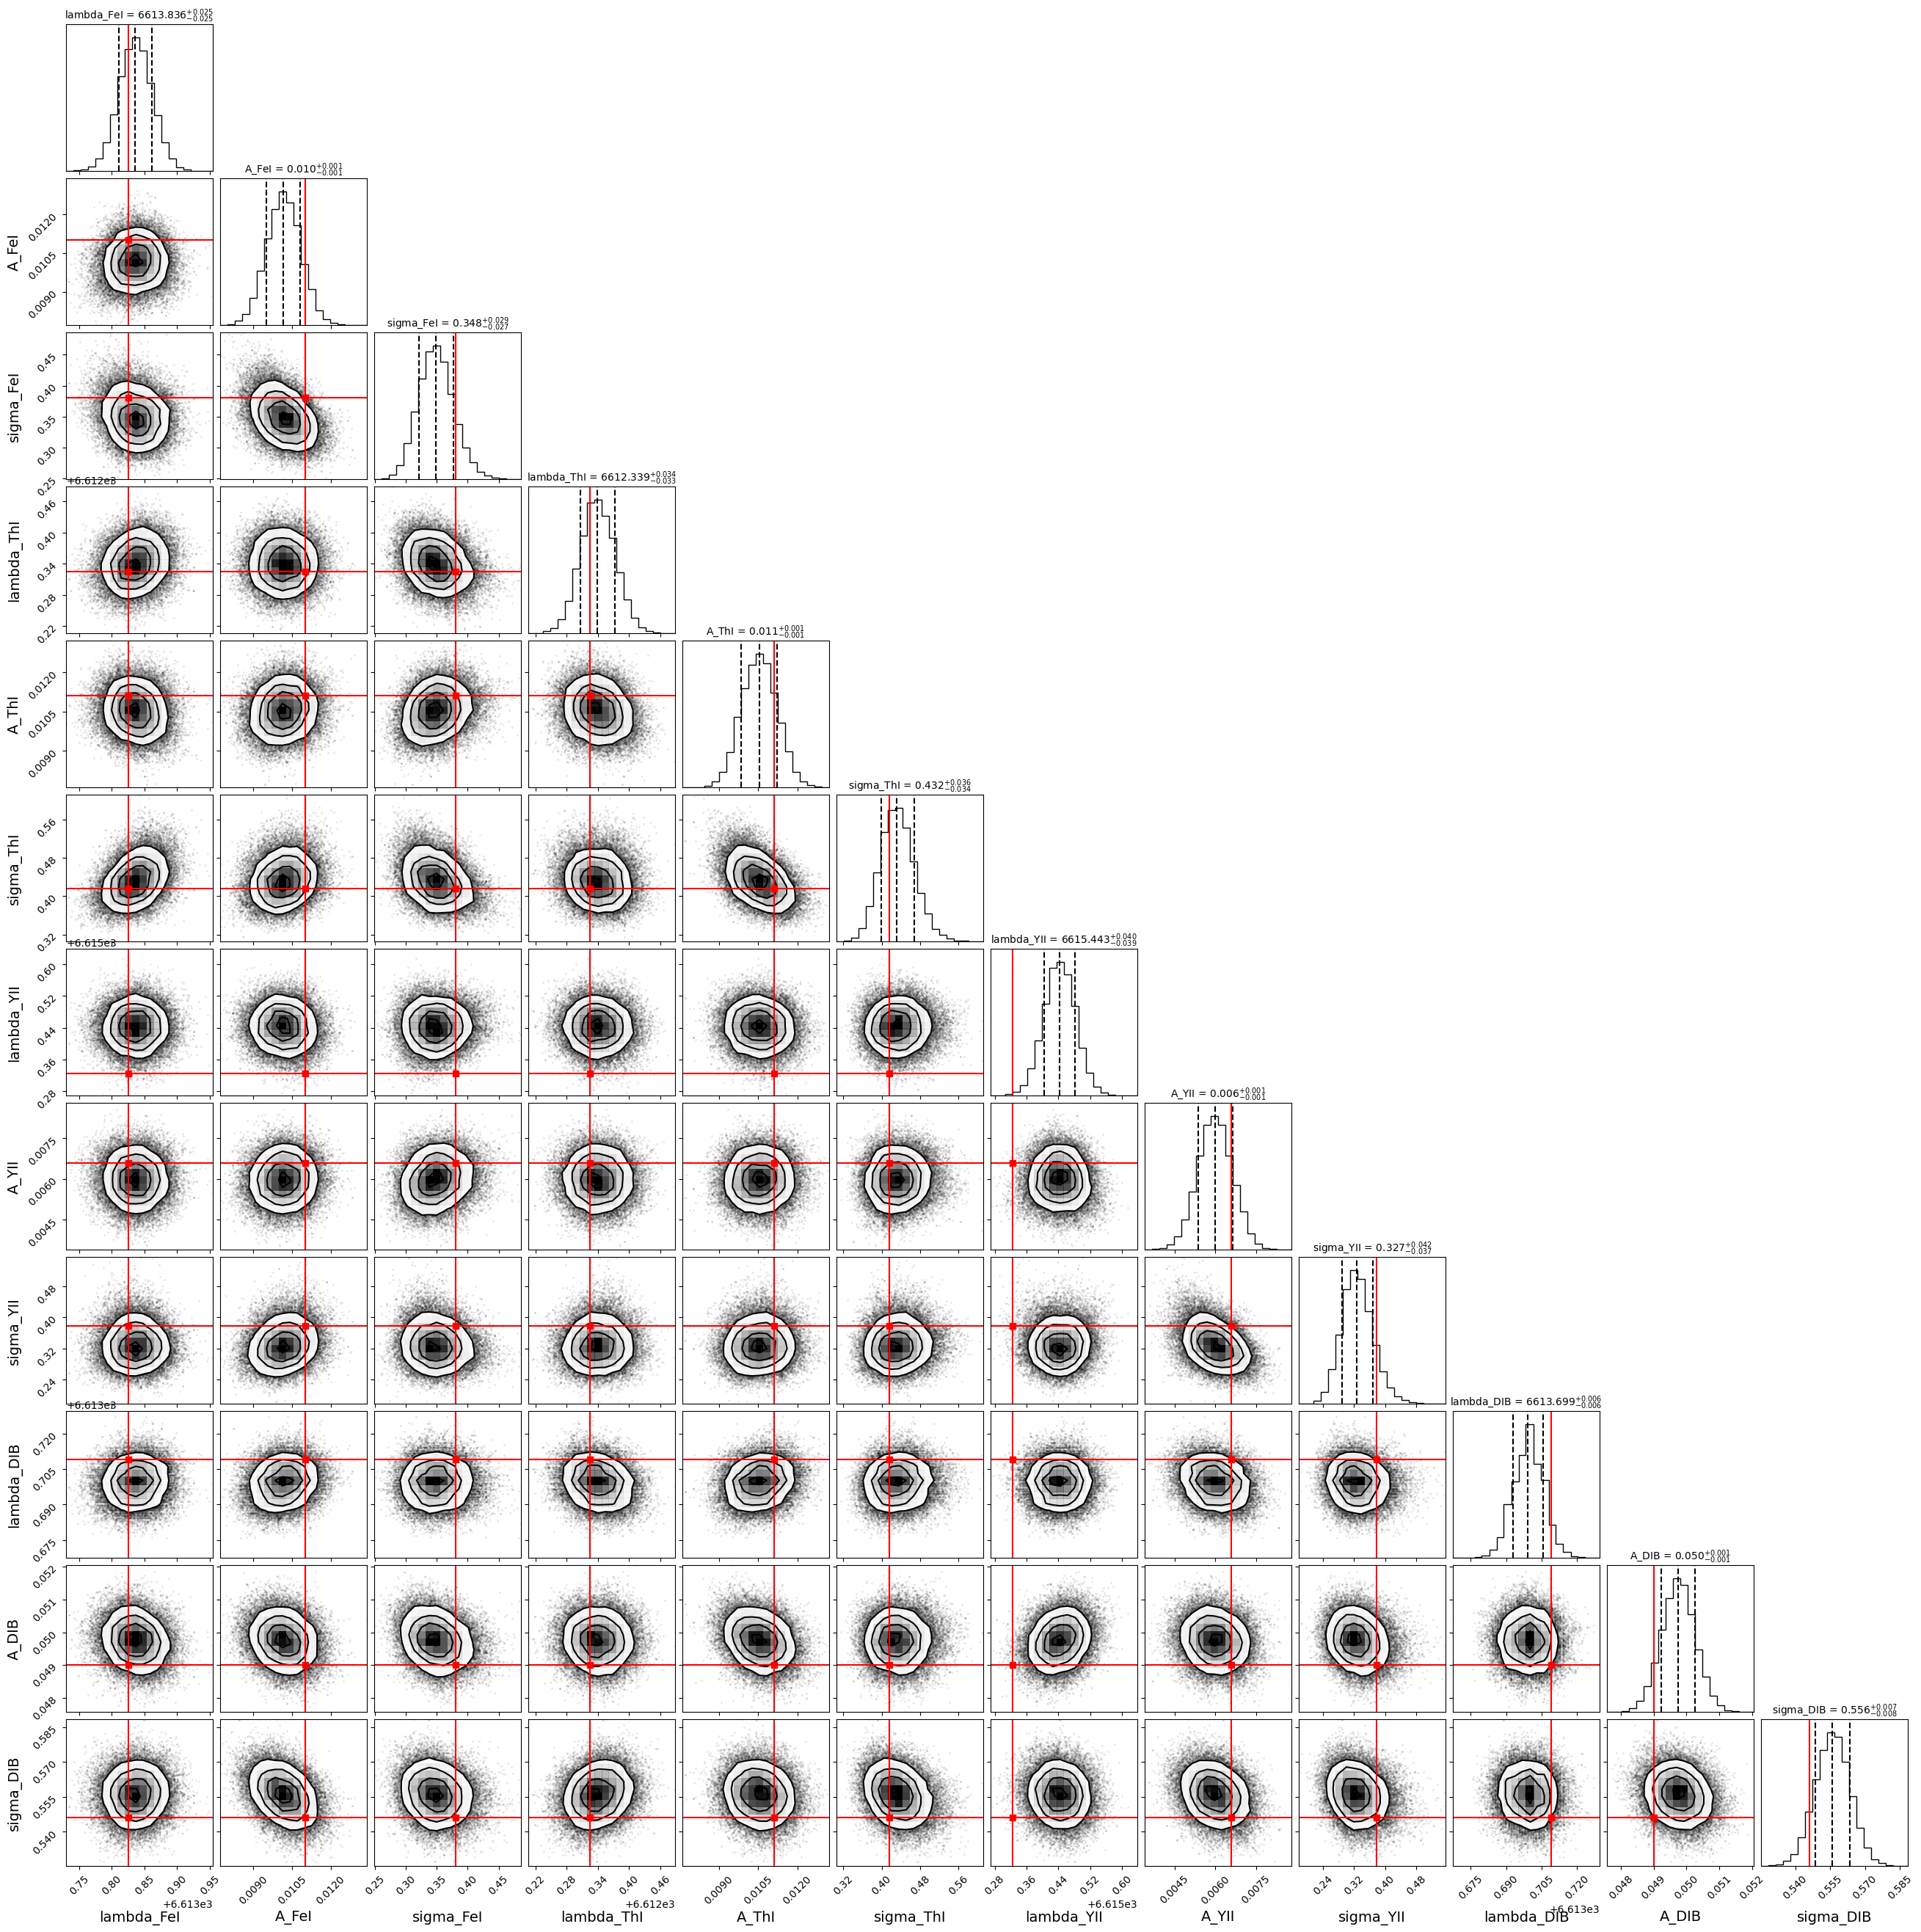

In [8]:
plotting.plot_corner(rows_b[1][5].samples, model3.param_names, truths=truth,
                     out=str(FIG / 'nb02_corner.png'))
plt.show()

## What to take away

* how many stellar lines you need is a question about the *resolution*, not about the number of
  lines in an atomic database: at $R=7500$ the blended trio near $6613.7\,\rm\AA$ behaves like a
  single line and one component is enough;
* when the lines are separated, ignoring them biases the DIB towards larger depth and width - the
  bias shows up in the DIB parameters, not in an obviously bad residual;
* $\Delta$AIC/$\Delta$BIC choose the right number of components, but evaluate them at a joint
  estimate (here the best sample of the chain), otherwise degenerate parameters can invert the
  ranking.